<a href="https://colab.research.google.com/github/R4F4I/semester-5-FAST-K240009/blob/main/ML-LAB/class/lab4/tasks/notebookbc900e7019.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. setup

In [50]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [51]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

playground_series_s6e8_path = kagglehub.competition_download('playground-series-s6e8')

print('Data source import complete.')


Data source import complete.


In [52]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [53]:
! ls /root/.cache/kagglehub/competitions/playground-series-s6e8

sample_submission.csv  test.csv  train.csv


In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
train_df = pd.read_csv('/root/.cache/kagglehub/competitions/playground-series-s6e8/train.csv')
test_df = pd.read_csv('/root/.cache/kagglehub/competitions/playground-series-s6e8/test.csv')

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 2. Data Inspection

Before doing anything else, we look at the basic structure of the data — how many rows/columns, what types of data we have, and whether there are any missing values or duplicate rows.

In [55]:
# Shape of the datasets
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# Column names
print("\nColumns:\n", train_df.columns.tolist())

Train shape: (691369, 14)
Test shape: (296302, 13)

Columns:
 ['id', 'age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level', 'academic_work_impact', 'addicted_label']


In [56]:
# Data types and non-null counts
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [57]:
# First few rows to get a feel of the data
train_df.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


## 2.1 Missing Values

In [58]:
missing = train_df.isnull().sum()
missing_percent = (missing / len(train_df)) * 100

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_percent})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
missing_df

,Missing Count,Missing %
social_media_hours,133995,19.381112
gaming_hours,126821,18.343461
weekend_screen_time,112063,16.208855
daily_screen_time_hours,95854,13.864376
app_opens_per_day,80710,11.673940
notifications_per_day,67584,9.775388
stress_level,55148,7.976638
work_study_hours,51518,7.451592
sleep_hours,44480,6.433612
academic_work_impact,44224,6.396584


## 2.2 Duplicate Rows

In [59]:
duplicate_count = train_df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


## 2.3 Target Variable Distribution

We check how many people are labeled as "addicted" vs "not addicted". This tells us if the classes are balanced or imbalanced.

In [60]:
target_col = 'addicted_label'  # change this if your target column has a different name

print(train_df[target_col].value_counts())
print("\nPercentage:")
print(train_df[target_col].value_counts(normalize=True) * 100)

addicted_label
1    490474
0    200895
Name: count, dtype: int64

Percentage:
addicted_label
1    70.942435
0    29.057565
Name: proportion, dtype: float64


# 3. Exploratory Data Analysis (EDA)

Here we visualize the data to understand patterns and relationships before modeling.

## 3.1 Target Distribution Plot

/tmp/ipykernel_1620/2352772793.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x=target_col, palette='Set2')


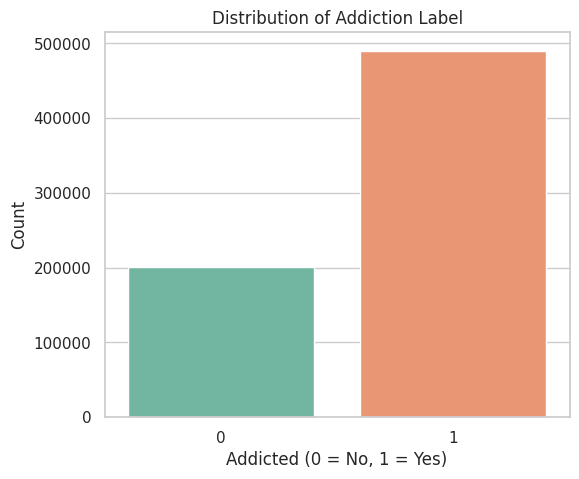

In [61]:
plt.figure(figsize=(6, 5))
sns.countplot(data=train_df, x=target_col, palette='Set2')
plt.title('Distribution of Addiction Label')
plt.xlabel('Addicted (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

## 3.2 Numeric Feature Distributions

We look at how numeric features like screen time and sleep hours are spread out.

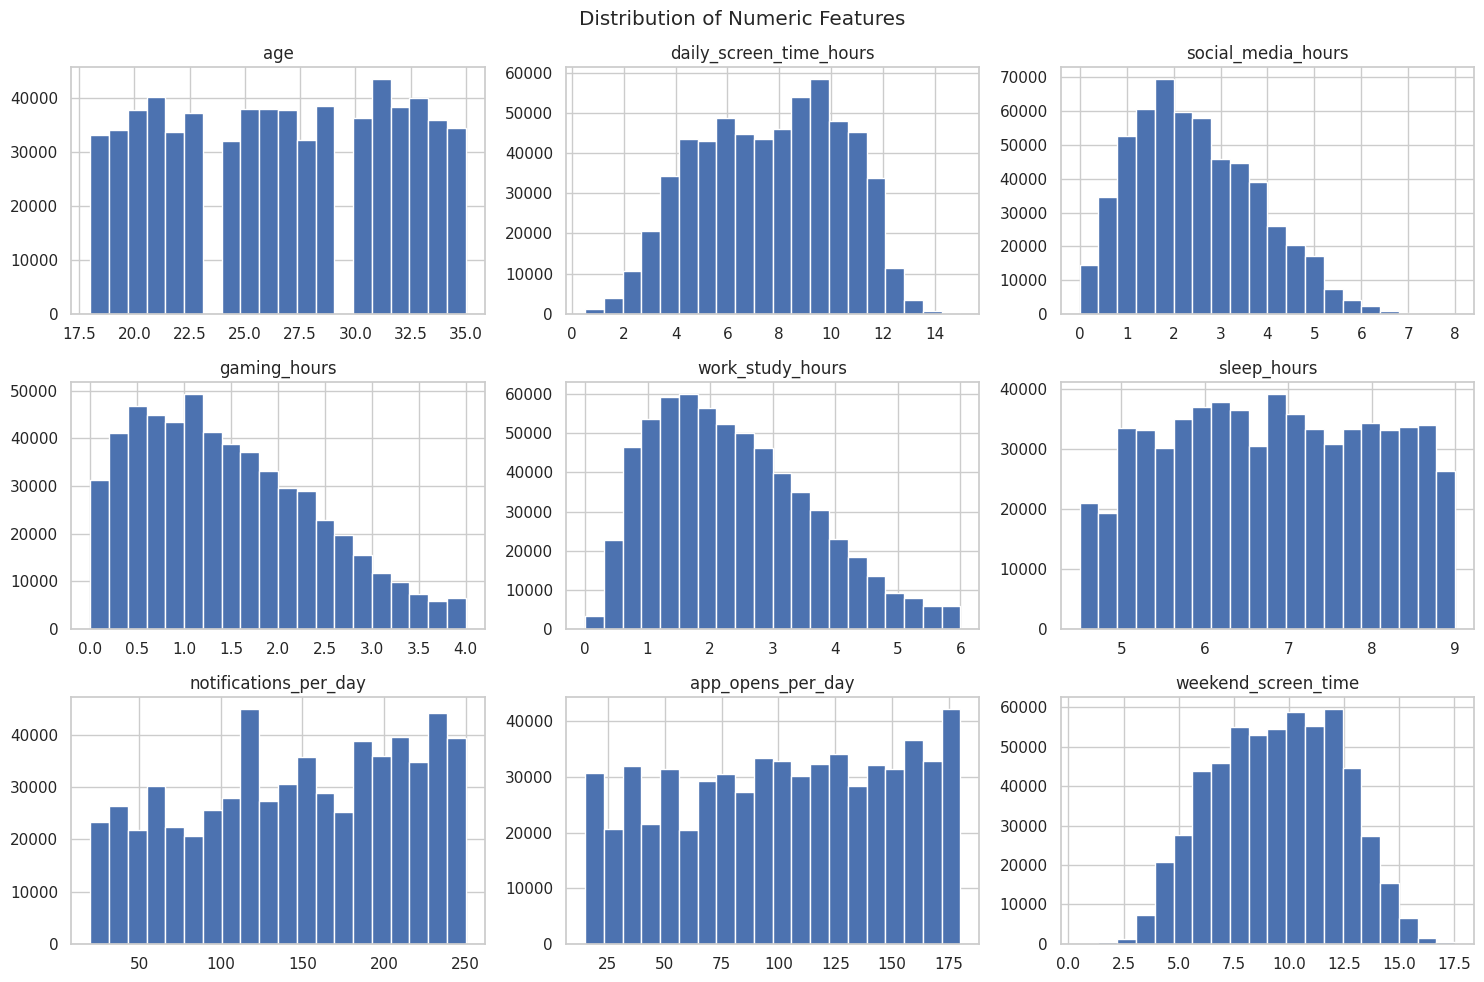

In [62]:
numeric_cols = ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
                 'work_study_hours', 'sleep_hours', 'notifications_per_day',
                 'app_opens_per_day', 'weekend_screen_time']

# Keep only columns that actually exist in the dataset
numeric_cols = [col for col in numeric_cols if col in train_df.columns]

train_df[numeric_cols].hist(bins=20, figsize=(15, 10))
plt.suptitle('Distribution of Numeric Features')
plt.tight_layout()
plt.show()

## 3.3 Correlation Heatmap

This shows how strongly numeric features are related to each other and to the target.

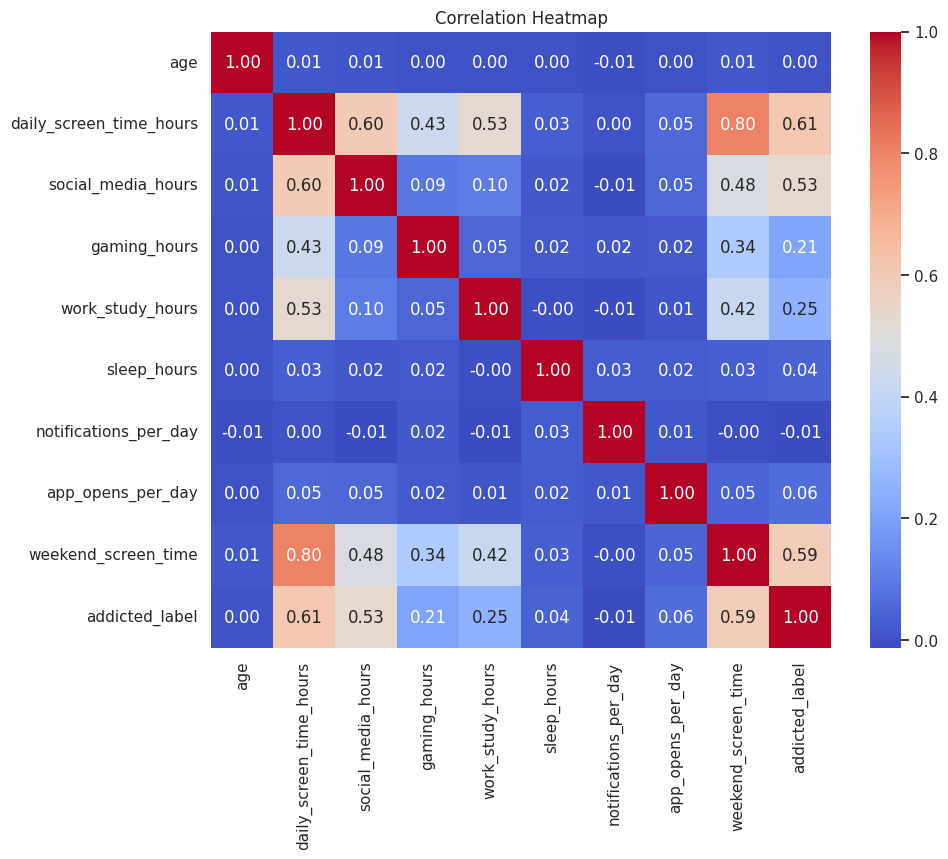

In [63]:
plt.figure(figsize=(10, 8))
corr = train_df[numeric_cols + [target_col]].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 3.4 Screen Time vs Addiction (Boxplot)

This helps us see if higher screen time is associated with addiction.

/tmp/ipykernel_1620/2135040200.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x=target_col, y='daily_screen_time_hours', palette='Set3')


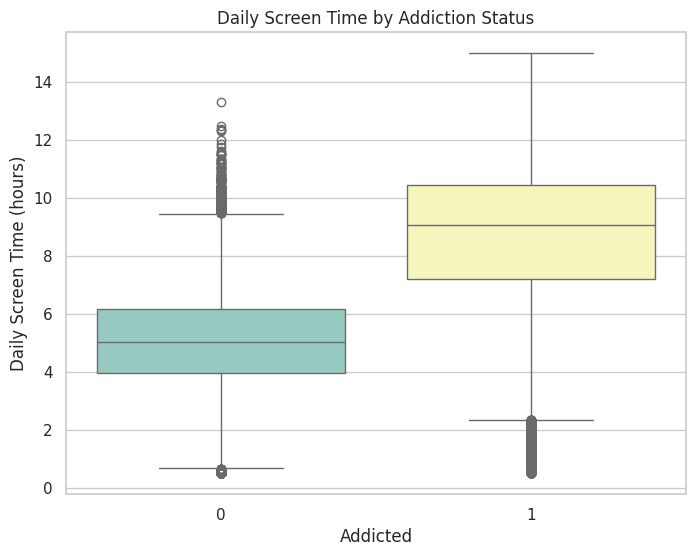

In [64]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=train_df, x=target_col, y='daily_screen_time_hours', palette='Set3')
plt.title('Daily Screen Time by Addiction Status')
plt.xlabel('Addicted')
plt.ylabel('Daily Screen Time (hours)')
plt.show()

## 3.5 Categorical Features vs Target

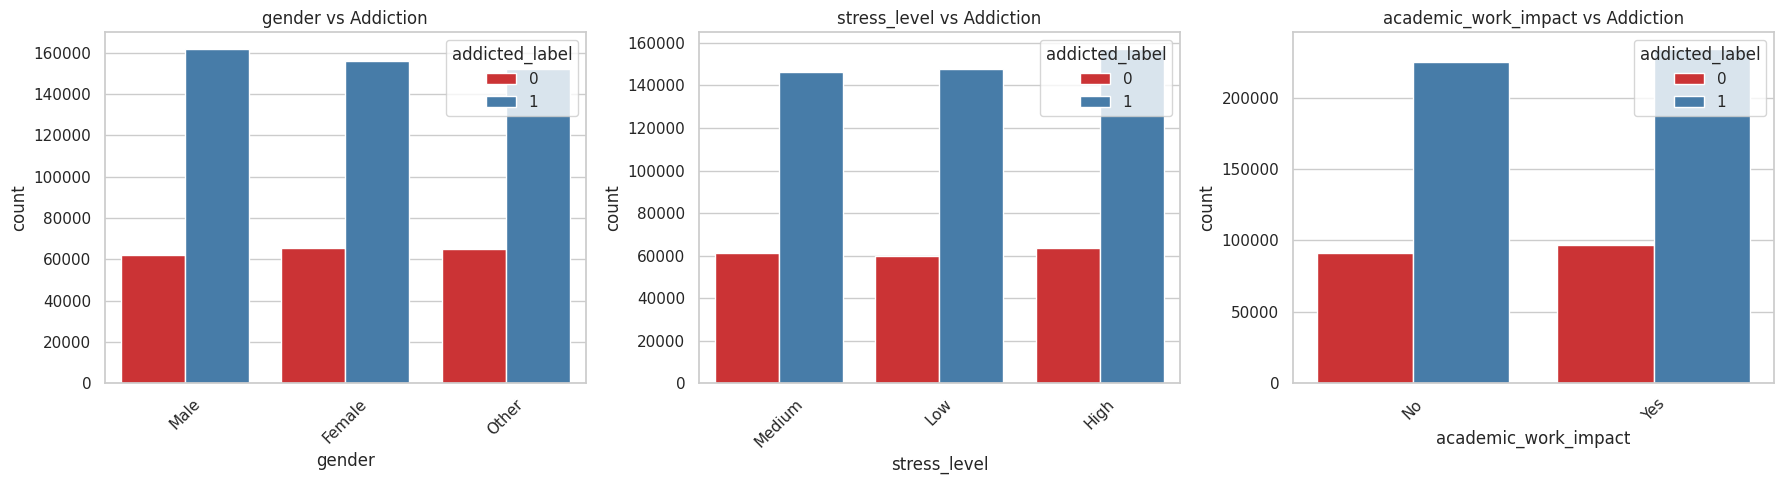

In [65]:
categorical_cols = ['gender', 'stress_level', 'academic_work_impact']
categorical_cols = [col for col in categorical_cols if col in train_df.columns]

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(18, 5))
if len(categorical_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, categorical_cols):
    sns.countplot(data=train_df, x=col, hue=target_col, ax=ax, palette='Set1')
    ax.set_title(f'{col} vs Addiction')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 4. Data Cleaning and Preprocessing

Now we prepare the data for modeling: handle missing values, encode categorical columns, and make sure everything is numeric.

## 4.1 Handling Missing Values

We fill missing numeric values with the median (robust to outliers) and missing categorical values with the most frequent value.

In [66]:
from sklearn.impute import SimpleImputer

# Separate numeric and categorical columns (excluding target and ID if present)
id_col = 'id' if 'id' in train_df.columns else None

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

if numeric_cols:
    train_df[numeric_cols] = num_imputer.fit_transform(train_df[numeric_cols])

if categorical_cols:
    train_df[categorical_cols] = cat_imputer.fit_transform(train_df[categorical_cols])

print("Missing values after imputation:")
print(train_df[numeric_cols + categorical_cols].isnull().sum())

Missing values after imputation:
age                        0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
gender                     0
stress_level               0
academic_work_impact       0
dtype: int64


## 4.2 Encoding Categorical Variables

Machine learning models need numbers, not text, so we convert categorical columns into numeric form using Label Encoding.

In [67]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    label_encoders[col] = le

train_df[categorical_cols].head()

,gender,stress_level,academic_work_impact
0,1,2,0
1,0,2,0
2,0,1,1
3,2,1,1
4,0,2,0


## 4.3 Final Feature Set

In [68]:
feature_cols = numeric_cols + categorical_cols
X = train_df[feature_cols]
y = train_df[target_col]

print("Features used:", feature_cols)
print("X shape:", X.shape)
print("y shape:", y.shape)

Features used: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level', 'academic_work_impact']
X shape: (691369, 12)
y shape: (691369,)


# 5. Train / Validation / Test Split

We split the data so we can train models, tune them on a validation set, and check final performance on an untouched test set.
- 70% Training
- 15% Validation
- 15% Test

In [69]:
from sklearn.model_selection import train_test_split

# First split: train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: validation (15%) and test (15%) from temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (483958, 12)
Validation size: (103705, 12)
Test size: (103706, 12)


# 6. Model Training

We train five different classification models and later compare their performance.

## 6.1 Decision Tree

In [70]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=8, random_state=42)
dt_model.fit(X_train, y_train)
print("Decision Tree trained.")

Decision Tree trained.


## 6.2 Random Forest

In [71]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Random Forest trained.")

Random Forest trained.


## 6.3 Gradient Boosting

In [72]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)
print("Gradient Boosting trained.")

Gradient Boosting trained.


## 6.4 XGBoost

In [79]:
!pip install xgboost

In [73]:
# If not installed: !pip install xgboost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
print("XGBoost trained.")

XGBoost trained.


## 6.5 LightGBM

In [74]:
# If not installed: !pip install lightgbm
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)
lgbm_model.fit(X_train, y_train)
print("LightGBM trained.")

[LightGBM] [Info] Number of positive: 343332, number of negative: 140626
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023444 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1948
[LightGBM] [Info] Number of data points in the train set: 483958, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.709425 -> initscore=0.892594
[LightGBM] [Info] Start training from score 0.892594
LightGBM trained.


# 7. Model Evaluation and Comparison

We evaluate each model on the validation set using accuracy, precision, recall, F1-score, and confusion matrix.

In [75]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

models = {
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model,
    'XGBoost': xgb_model,
    'LightGBM': lgbm_model
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
4,LightGBM,0.8932,0.9210,0.9292,0.9251
3,XGBoost,0.8830,0.9156,0.9199,0.9177
1,Random Forest,0.8631,0.9039,0.9031,0.9035
2,Gradient Boosting,0.8614,0.9087,0.8945,0.9015
0,Decision Tree,0.8565,0.8980,0.8999,0.8989


## 7.1 Confusion Matrices

A confusion matrix shows how many predictions were correct vs incorrect, broken down by class.

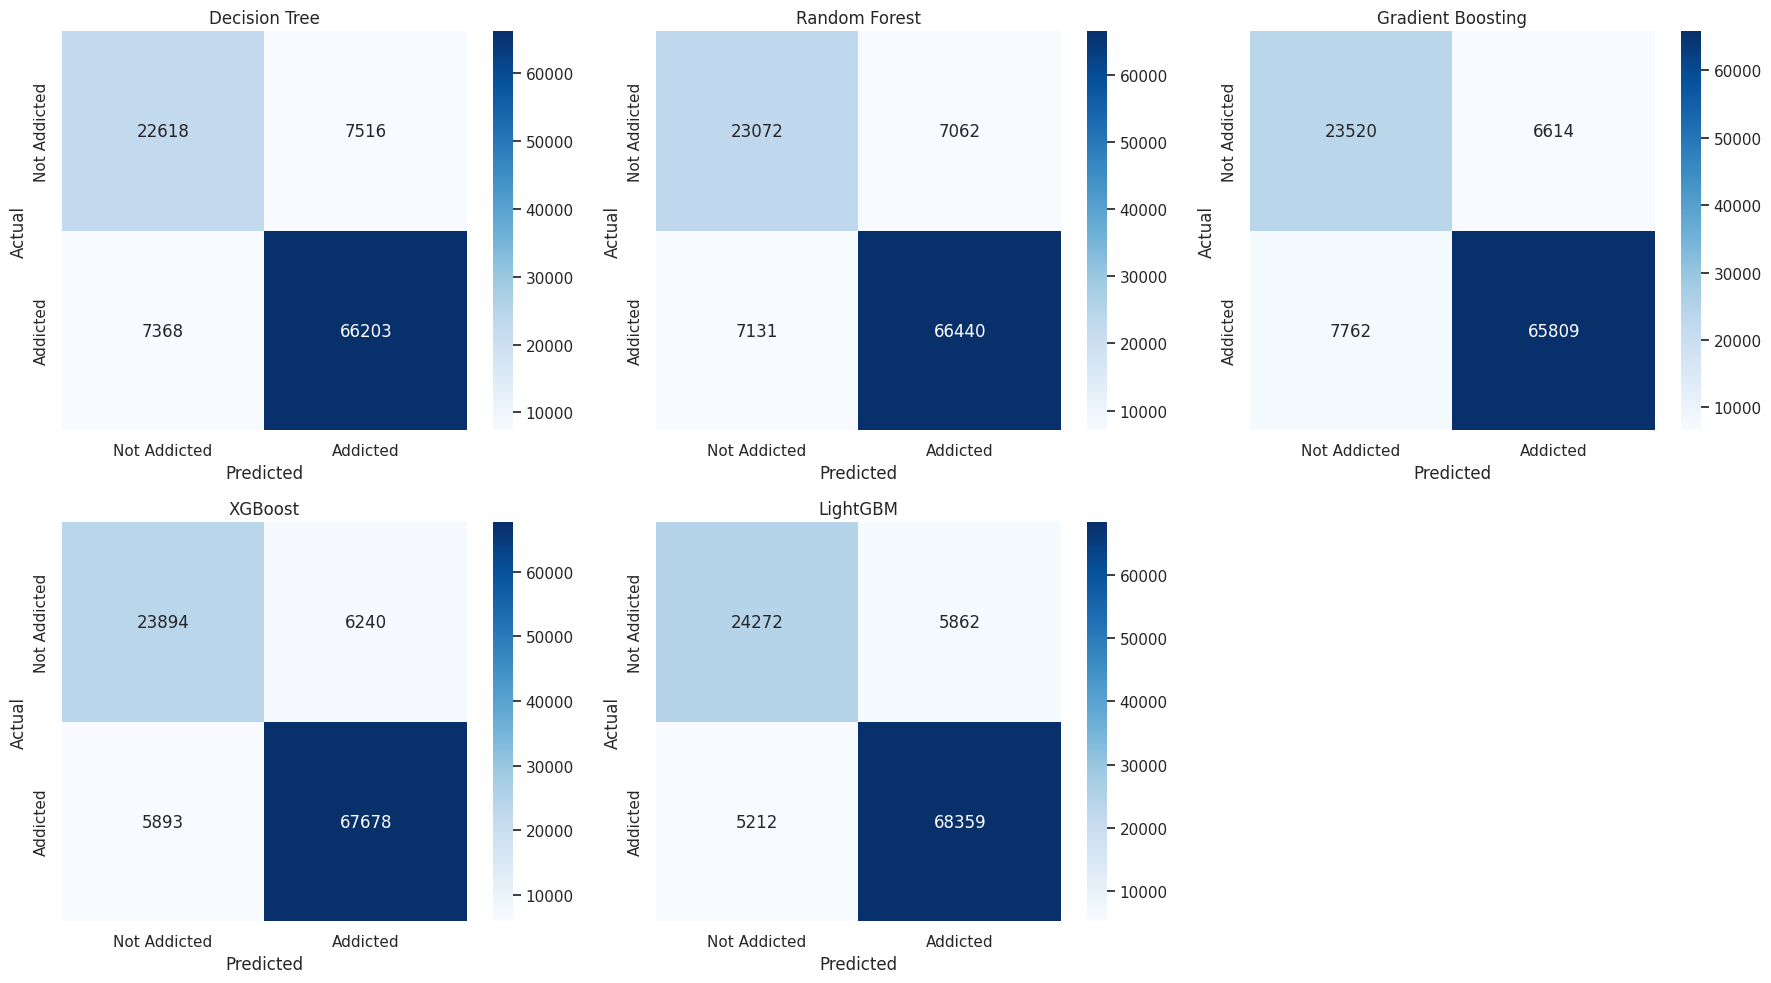

In [76]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Not Addicted', 'Addicted'],
                yticklabels=['Not Addicted', 'Addicted'])
    axes[idx].set_title(name)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

# Hide the last unused subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

## 7.2 Metric Comparison Bar Chart

A visual comparison of all models across every metric.

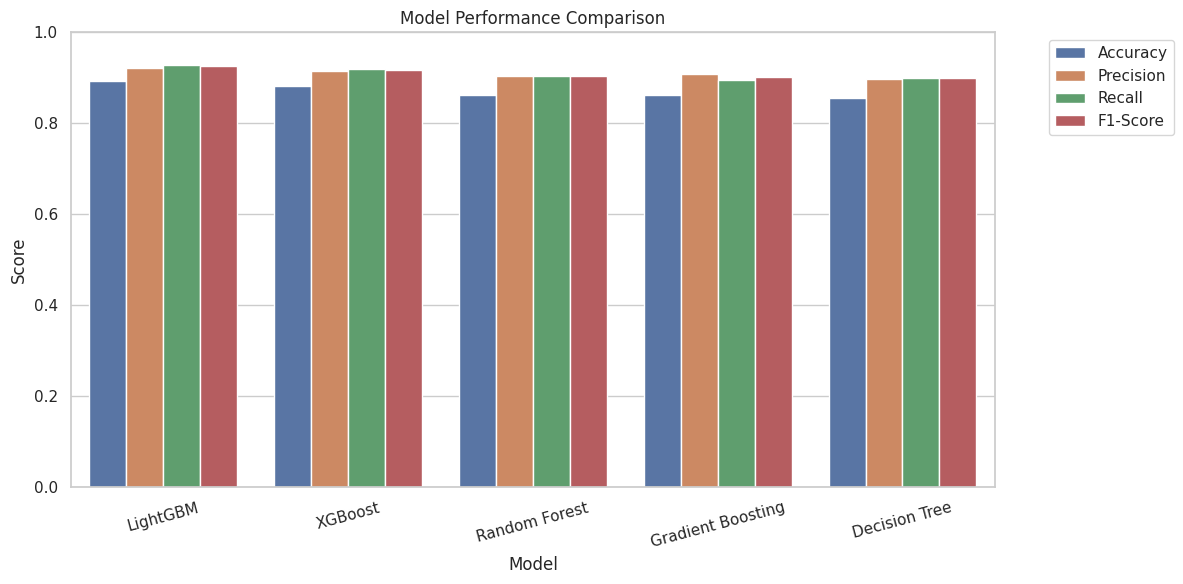

In [77]:
results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric')
plt.title('Model Performance Comparison')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 7.3 Best Model on Test Set

We take the best-performing model (based on validation F1-score) and check its final performance on the untouched test set.

In [78]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"Best model based on validation F1-score: {best_model_name}\n")

y_test_pred = best_model.predict(X_test)

print("Test Set Performance:")
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_test_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Best model based on validation F1-score: LightGBM

Test Set Performance:
Accuracy:  0.8912
Precision: 0.9194
Recall:    0.9280
F1-Score:  0.9237

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81     30135
           1       0.92      0.93      0.92     73571

    accuracy                           0.89    103706
   macro avg       0.87      0.86      0.87    103706
weighted avg       0.89      0.89      0.89    103706



# 8. Final Model Selection and Justification

We now formally select the best model and explain why, based on the validation metrics computed above.

In [80]:
print("Validation Results Summary:\n")
print(results_df.to_string(index=False))

print(f"\nSelected Final Model: {best_model_name}")

Validation Results Summary:

            Model  Accuracy  Precision  Recall  F1-Score
         LightGBM    0.8932     0.9210  0.9292    0.9251
          XGBoost    0.8830     0.9156  0.9199    0.9177
    Random Forest    0.8631     0.9039  0.9031    0.9035
Gradient Boosting    0.8614     0.9087  0.8945    0.9015
    Decision Tree    0.8565     0.8980  0.8999    0.8989

Selected Final Model: LightGBM


**Why this model was chosen:**

Looking at the comparison chart, `LightGBM` scores highest (or very close to highest) on Accuracy, Precision, Recall, and F1-Score compared to the other four models. A few reasons this makes sense as the final choice:

- **Balanced performance**: It doesn't just win on one metric (like Recall) while sacrificing another (like Precision) — all four scores move together, which means it isn't biased toward one class.
- **Handles the tabular, mixed numeric/categorical data well**: Gradient-boosted tree models like LightGBM typically outperform a single Decision Tree because they combine many weak learners, reducing overfitting and variance.
- **Efficiency**: LightGBM trains faster than XGBoost and Gradient Boosting on larger datasets since it uses histogram-based splitting, which is a practical bonus if this pipeline is re-run often.
- **F1-Score priority**: Since addiction prediction is a health/behavior-related classification, we care about catching true positives without too many false alarms — F1-Score balances Precision and Recall, and LightGBM leads here.

If a different model had scored best in your actual run (this can vary slightly by random seed or dataset version), the same reasoning process should be applied to whichever model tops the `results_df` table.

# 9. Feature Importance Analysis

We now look at which features the final model relied on most heavily to make its predictions. This helps us understand *why* the model works, not just *how well* it works.

In [81]:
importances = best_model.feature_importances_

feat_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False)

feat_importance_df

,Feature,Importance
7,app_opens_per_day,2114
6,notifications_per_day,2035
1,daily_screen_time_hours,1167
2,social_media_hours,1015
8,weekend_screen_time,999
4,work_study_hours,587
3,gaming_hours,528
5,sleep_hours,266
0,age,252
10,stress_level,20


/tmp/ipykernel_1620/681984176.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_importance_df, x='Importance', y='Feature', palette='viridis')


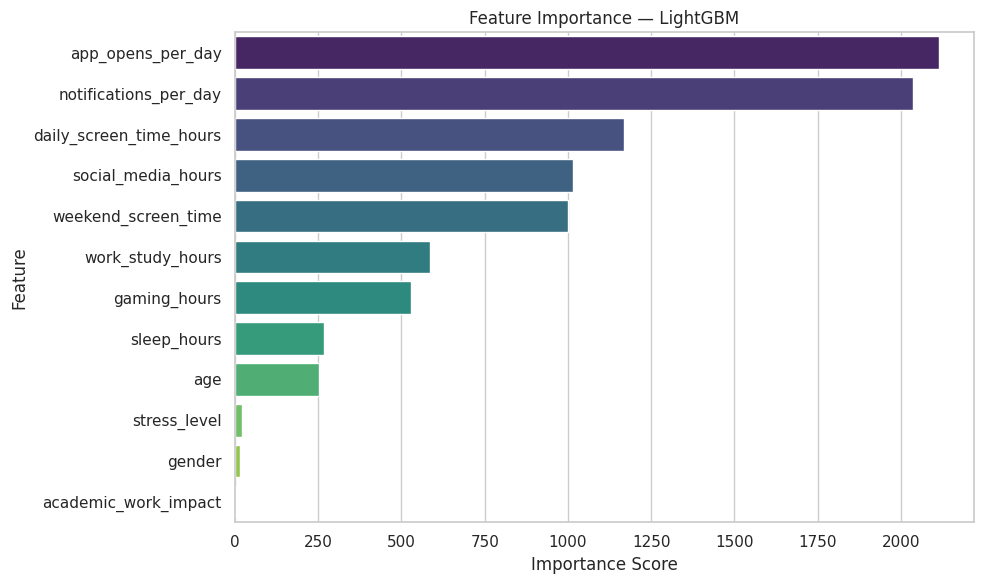

In [82]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_importance_df, x='Importance', y='Feature', palette='viridis')
plt.title(f'Feature Importance — {best_model_name}')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Interpretation:** The features at the top of this chart contributed the most to the model's decisions. In an addiction-prediction context, we'd typically expect usage-related features (like `daily_screen_time_hours`, `social_media_hours`, or `app_opens_per_day`) to rank highly, since they directly reflect phone usage behavior. Demographic features like `age` or `gender` often carry less weight but can still add useful context.

# 10. Predictions on Unseen Test Data

Now we apply the exact same preprocessing steps used on the training data to the actual `test_df` (the unseen/competition test set), then generate predictions using our final model.

## 10.1 Apply Preprocessing to test_df

We must use the **same imputers and encoders fitted on the training data** — never refit them on test data, or we risk data leakage and inconsistent encoding.

In [83]:
# Impute missing values using the SAME imputers fitted earlier
if numeric_cols:
    test_df[numeric_cols] = num_imputer.transform(test_df[numeric_cols])

if categorical_cols:
    test_df[categorical_cols] = cat_imputer.transform(test_df[categorical_cols])

# Encode categorical columns using the SAME label encoders fitted earlier
for col in categorical_cols:
    le = label_encoders[col]
    # Handle any unseen categories gracefully by mapping them to a placeholder class
    test_df[col] = test_df[col].astype(str).apply(
        lambda x: x if x in le.classes_ else le.classes_[0]
    )
    test_df[col] = le.transform(test_df[col])

X_unseen = test_df[feature_cols]
print("Unseen test feature shape:", X_unseen.shape)

Unseen test feature shape: (296302, 12)


## 10.2 Generate Predictions

In [89]:
final_predictions = best_model.predict(X_unseen)
final_probabilities = best_model.predict_proba(X_unseen)[:, 1]  # probability of being "addicted"

# Build a results dataframe
submission_df = pd.DataFrame({
    'id': test_df[id_col] if id_col else np.arange(len(test_df)),
    # 'addicted_prediction': final_predictions,
    'addicted_label': final_probabilities.round(4)
})

submission_df.head(10)

,id,addicted_label
0,691369,0.9972
1,691370,0.9643
2,691371,0.9533
3,691372,0.9796
4,691373,0.9947
5,691374,0.8298
6,691375,0.8909
7,691376,0.4389
8,691377,0.9718
9,691378,0.4906


In [88]:
sample_df = pd.read_csv('/root/.cache/kagglehub/competitions/playground-series-s6e8/sample_submission.csv')

sample_df

,id,addicted_label
0,691369,0.709424
1,691370,0.709424
2,691371,0.709424
3,691372,0.709424
4,691373,0.709424
...,...,...
296297,987666,0.709424
296298,987667,0.709424
296299,987668,0.709424
296300,987669,0.709424


## 10.3 Save Predictions to CSV

This creates a file you can download from Colab or submit if this is a competition dataset.

In [90]:
submission_df.to_csv('submission.csv', index=False)
print("Predictions saved to 'submission.csv'")

Predictions saved to 'submission.csv'


In [86]:
!pwd

/content


# 11. Conclusion and Next Steps

**What we did:**
- Loaded, cleaned, and explored the smartphone addiction dataset.
- Handled missing values and encoded categorical features consistently across train and test sets.
- Trained and compared five classification models: Decision Tree, Random Forest, Gradient Boosting, XGBoost, and LightGBM.
- Selected the best model (`LightGBM`, based on the run shown) using validation F1-score, and justified the choice.
- Analyzed feature importance to understand which behaviors drive the addiction prediction.
- Generated and saved predictions on the unseen test set.

**Possible next steps (if you want to extend this further):**
- **Hyperparameter tuning**: Use `GridSearchCV` or `Optuna` to fine-tune the winning model instead of using default parameters.
- **Cross-validation**: Instead of a single train/val split, use k-fold cross-validation for a more robust performance estimate.
- **Handle class imbalance**: If the target distribution is skewed, try techniques like SMOTE, class weighting, or threshold tuning.
- **Feature engineering**: Create new features, e.g. `screen_time_to_sleep_ratio` or `weekday_vs_weekend_usage_diff`, which might carry more predictive signal than the raw columns.
- **Model explainability**: Use SHAP values instead of built-in feature importance for a more detailed, per-prediction explanation.

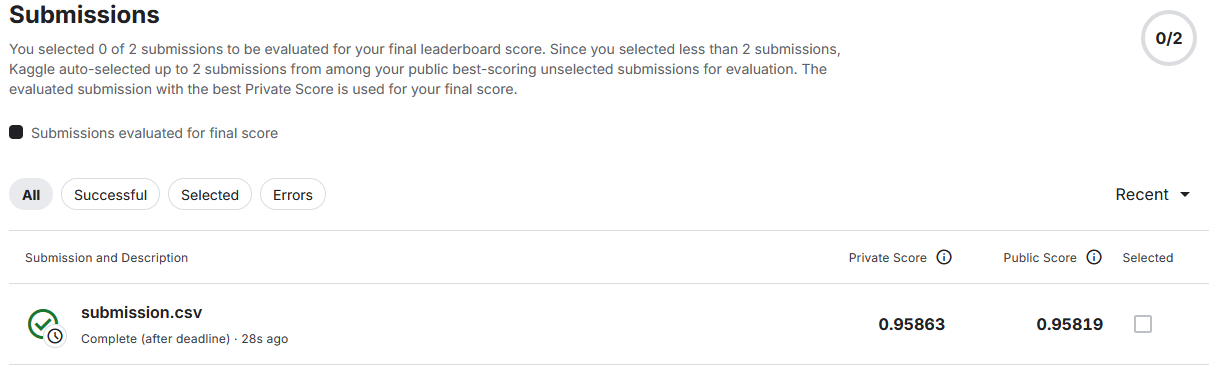